##### Queying database using prompt

db: mysql

In [37]:
import pymysql
from sqlalchemy import  create_engine, text
import os
from dotenv import load_dotenv
load_dotenv()

HOST=os.environ.get('MY_SQL_HOST')
PORT=os.environ.get('MY_SQL_PORT')
USER=os.environ.get('MY_SQL_USR')
PW=os.environ.get('MY_SQL_PW')
CM_DB=os.environ.get('MY_SQL_DB_CLASSIC_MODEL')

def get_connection():
    """Get mysql db conncetion using pymysql"""
    conn = pymysql.connect(
        host=HOST,
        port=int(PORT),
        user=USER,
        password=PW,
        db=CM_DB
    )

    return conn
    
engine = create_engine("mysql+pymysql://", creator=get_connection)

conn = engine.connect()
# res=conn.execute(text('Select * from customers LIMIT 1'))
# res.fetchall()


In [38]:
##llm
from langchain_groq import ChatGroq
os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
llm = ChatGroq(model="qwen/qwen3-32b")

In [39]:
from langchain_community.utilities.sql_database import SQLDatabase
db = SQLDatabase(engine)

In [41]:
from langchain_community.agent_toolkits.sql.toolkit import SQLDatabaseToolkit
toolkit = SQLDatabaseToolkit(db=db, llm=llm)

In [42]:
toolkit.get_tools()

[QuerySQLDatabaseTool(description="Input to this tool is a detailed and correct SQL query, output is a result from the database. If the query is not correct, an error message will be returned. If an error is returned, rewrite the query, check the query, and try again. If you encounter an issue with Unknown column 'xxxx' in 'field list', use sql_db_schema to query the correct table fields.", db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002038BBF81A0>),
 InfoSQLDatabaseTool(description='Input to this tool is a comma-separated list of tables, output is the schema and sample rows for those tables. Be sure that the tables actually exist by calling sql_db_list_tables first! Example Input: table1, table2, table3', db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002038BBF81A0>),
 ListSQLDatabaseTool(db=<langchain_community.utilities.sql_database.SQLDatabase object at 0x000002038BBF81A0>),
 QuerySQLCheckerTool(description='Use this tool to 

In [45]:
from langchain_classic import hub

prompt_template = hub.pull("langchain-ai/sql-agent-system-prompt")

assert len(prompt_template.messages) == 1
print(prompt_template.input_variables)
system_message = prompt_template.format(dialect="SQLite", top_k=5)

['dialect', 'top_k']


In [46]:
from langchain.agents import create_agent
agent = create_agent(llm, tools=toolkit.get_tools(), system_prompt=system_message)

In [47]:
query = "What are the products that was orderd by Atelier graphique  on 20 May 2003?"
events = agent.stream(
    {"messages": [("user", query)]},
    stream_mode="values",
)

for event in events:
    event["messages"][-1].pretty_print()

================================ Human Message =================================

What are the products that was orderd by Atelier graphique  on 20 May 2003?
================================== Ai Message ==================================
Tool Calls:
  sql_db_list_tables (8n9dm09qe)
 Call ID: 8n9dm09qe
  Args:
    tool_input:
================================= Tool Message =================================
Name: sql_db_list_tables

customers, employees, offices, orderdetails, orders, payments, productlines, products
================================== Ai Message ==================================
Tool Calls:
  sql_db_query (qt4nt98xy)
 Call ID: qt4nt98xy
  Args:
    query: SELECT p.productName FROM customers c JOIN orders o ON c.customerNumber = o.customerNumber JOIN orderdetails od ON o.orderNumber = od.orderNumber JOIN products p ON od.productCode = p.productCode WHERE c.customerName = 'Atelier graphique' AND o.orderDate = '2003-05-20' LIMIT 5;
================================= Tool Me

##### From mysql cli

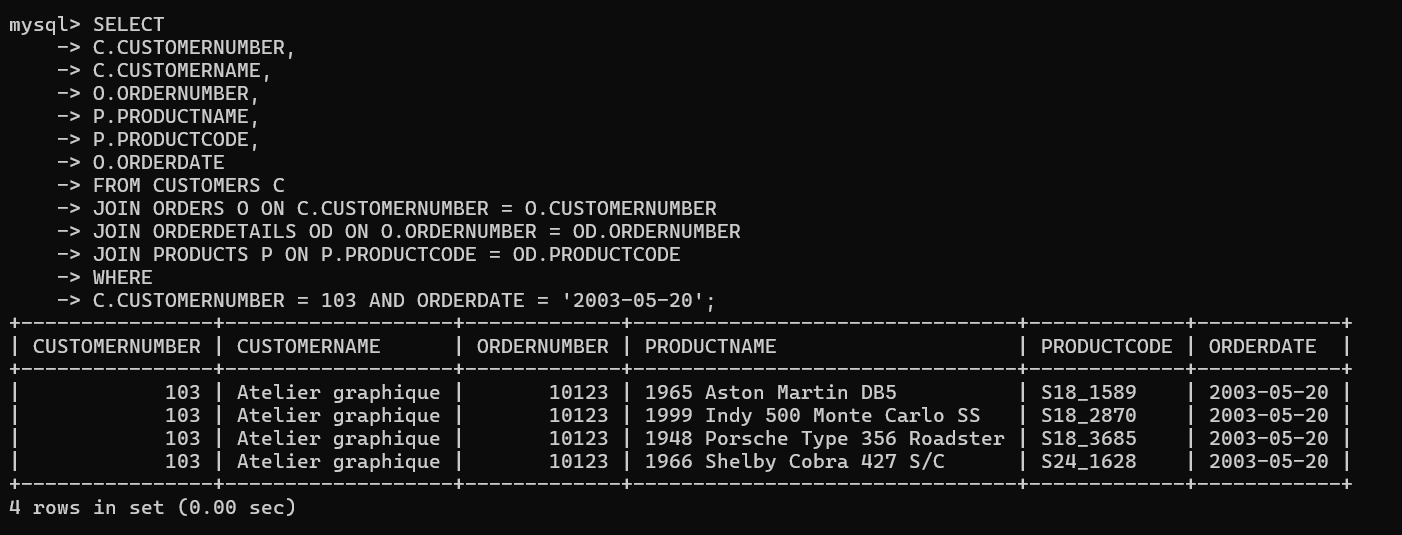